In [2]:
# 1: Importing the Libraries required
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1.1: Loading the dataset
file_path = 'onlinefraud.csv'
df = pd.read_csv(file_path)
df = df.sample(frac=1, random_state=42)

# 1.2: Checking data shape and preview
print("Dataset shape after sampling:", df.shape)
df.head()

Dataset shape after sampling: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


In [3]:
# 2: Knowing the basic information from the dataset

#Gives column names and thier datatypes
df.info()

#Knowing about the Descriptive statistics
print(df.describe().T)

#Types of transactions present in the dataset
print("Transaction type counts\n")
print(df['type'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 6362620 entries, 3737323 to 1692743
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 582.5+ MB
                    count          mean           std  min       25%  \
step            6362620.0  2.433972e+02  1.423320e+02  1.0    156.00   
amount          6362620.0  1.798619e+05  6.038582e+05  0.0  13389.57   
oldbalanceOrg   6362620.0  8.338831e+05  2.888243e+06  0.0      0.00   
newbalanceOrig  6362620.0  8.551137e+05  2.924049e+06  0.0      0.00   
oldbalanceDest  6362620.0  1.100702e+06  3.399180e+06  0.0      0.00   
newbalanceDes

In [4]:
#3.Data Preparation

#3.1 Data Discretization

#STEP-1: Analyzing distribution of transaction amounts
print('Transaction Amount Statistics:')
print(df['amount'].describe())

#STEP-2: Define bins (ranges for discretization)
bins=[0, 10000, 100000, 1000000, df['amount'].max()]
labels=['Low', 'Medium', 'High', 'Very High']

#STEP-3: Categorical Column
df['amount_category'] = pd.cut(df['amount'], bins=bins, labels=labels, include_lowest=True)

#STEP-4: Check Results
print("\n Discretization completed. Sample Output: ")
print(df[['amount','amount_category']].head(10))

#STEP-5: Verifying counts per category
print("\nCategory Distribution: ")
print(df['amount_category'].value_counts())

Transaction Amount Statistics:
count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

 Discretization completed. Sample Output: 
             amount amount_category
3737323   330218.42            High
264914     11647.08          Medium
85647     152264.21            High
5899326  1551760.63       Very High
2544263    78172.30          Medium
3494160      915.13             Low
2331654    20603.87          Medium
1414955    58605.72          Medium
2938135     4865.11             Low
6133806   118131.63            High

Category Distribution: 
amount_category
High         2706696
Medium       2239207
Low          1286091
Very High     130626
Name: count, dtype: int64


In [5]:
#3.2 Data Cleaning

#For checking if there are any null values, in this case the data is clean
print("Checking Missing values\n")
missing_values = df.isnull().sum()
print(f"Number of missing values: {missing_values}")

#Dropping all the missing values and null values
df.dropna(inplace=True)

#Checking for duplicates, no duplicates are present
duplicated_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicated_count}")
if duplicated_count > 0:
  df.drop_duplicates(inplace = True)
  print("Duplicate rows removed\n")


# Creating logical features for Identifing the sender's balance mismatch and receiver's mismatch
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

#If the account money starts and ends with zero after a transaction
df['isZeroDest'] = ((df['newbalanceDest'] == 0) & (df['oldbalanceDest'] == 0)).astype(int)

#Remove irrelevant columns that are not necessary
print("Dropping irrelevant columns (nameOrig, nameDest)...\n")
df = df.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')
print(f"Columns dropped. New data frame shape {df.shape}")
print("Current dataframe head after cleaning")
print(df.head())

#Checking for negative or invalid numeric values and replacing that values with zeros
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
for col in numeric_cols:
    if (df[col] < 0).any():
        print(f"Found negative values in {col}. Replacing with 0.")
        df[col] = df[col].apply(lambda x: max(x, 0))

#Reseting index after drops
df.reset_index(drop=True, inplace=True)

print("\nData cleaning complete!")

#Shape of the dataset after data cleaning
print("Shape after cleaning:", df.shape)

Checking Missing values

Number of missing values: step               0
type               0
amount             0
nameOrig           0
oldbalanceOrg      0
newbalanceOrig     0
nameDest           0
oldbalanceDest     0
newbalanceDest     0
isFraud            0
isFlaggedFraud     0
amount_category    0
dtype: int64
Number of duplicate rows: 0
Dropping irrelevant columns (nameOrig, nameDest)...

Columns dropped. New data frame shape (6362620, 13)
Current dataframe head after cleaning
         step      type      amount  oldbalanceOrg  newbalanceOrig  \
3737323   278   CASH_IN   330218.42       20866.00       351084.42   
264914     15   PAYMENT    11647.08       30370.00        18722.92   
85647      10   CASH_IN   152264.21      106589.00       258853.21   
5899326   403  TRANSFER  1551760.63           0.00            0.00   
2544263   206   CASH_IN    78172.30     2921331.58      2999503.88   

         oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
3737323       452419.57 

In [6]:
#3.3 Data Integration
#As there is no requirement for additional dataset, this step is not required in this case


Descriptive Statistics
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  \
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06   
mean     1.100702e+06    1.224996e+06  1.290820e-03    2.514687e-06   
std      3.399180e+06    3.674129e+06  3.590480e-02    1.585775e-03   
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00   
25%     

/tmp/ipykernel_160/3598786464.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=df, palette='pastel')


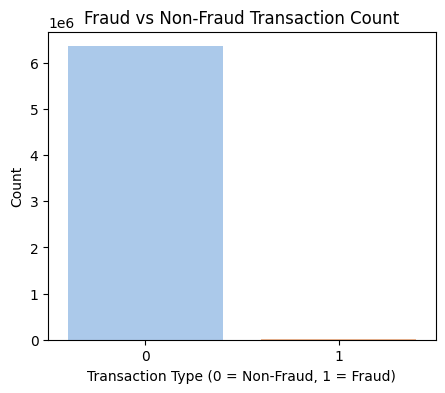


Fraud Percentage in Dataset:
 isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


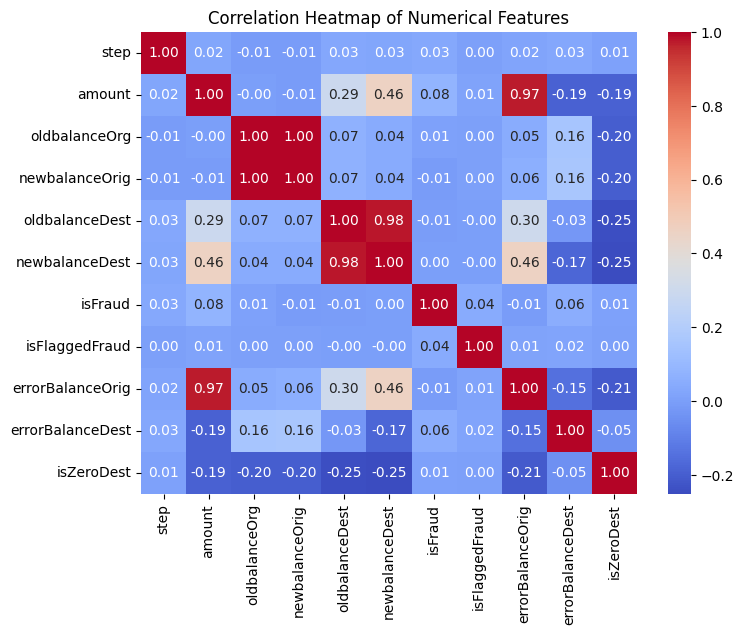

/tmp/ipykernel_160/3598786464.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y=col, data=df, palette='Set2')


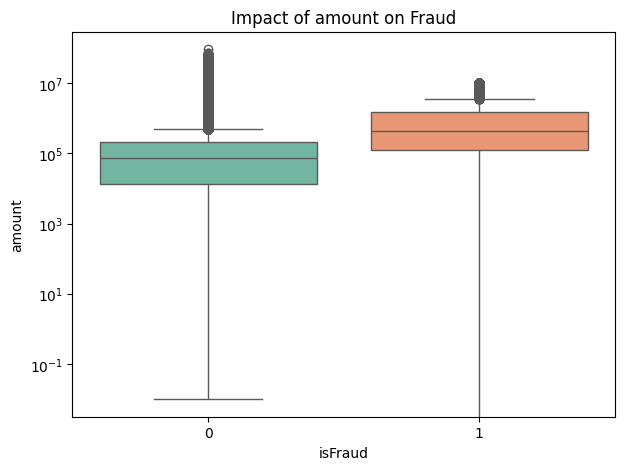

/tmp/ipykernel_160/3598786464.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y=col, data=df, palette='Set2')


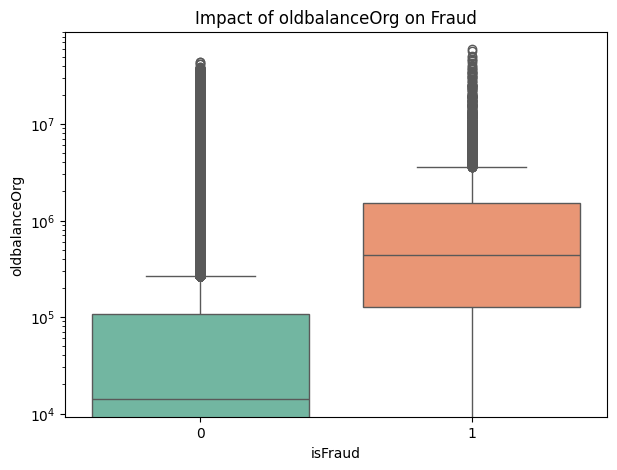

/tmp/ipykernel_160/3598786464.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y=col, data=df, palette='Set2')


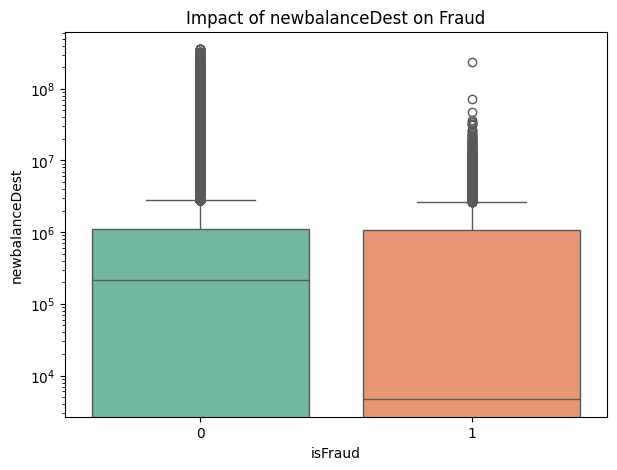

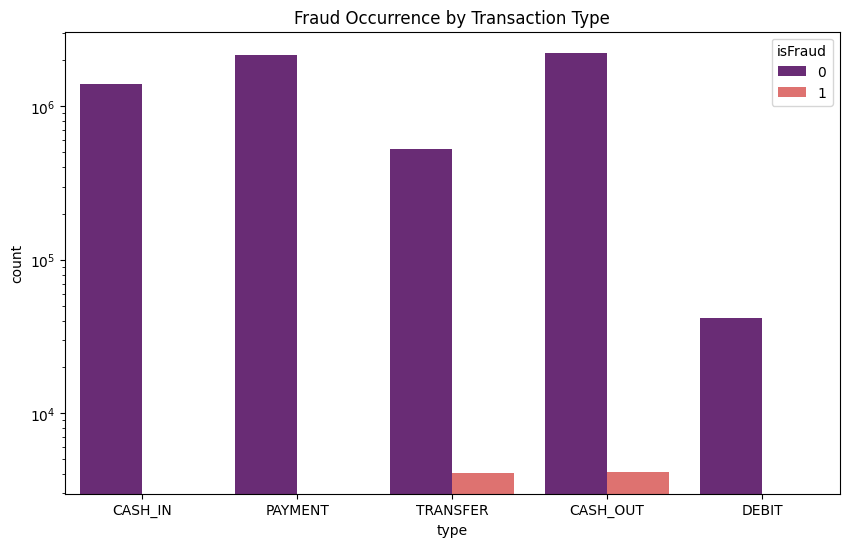

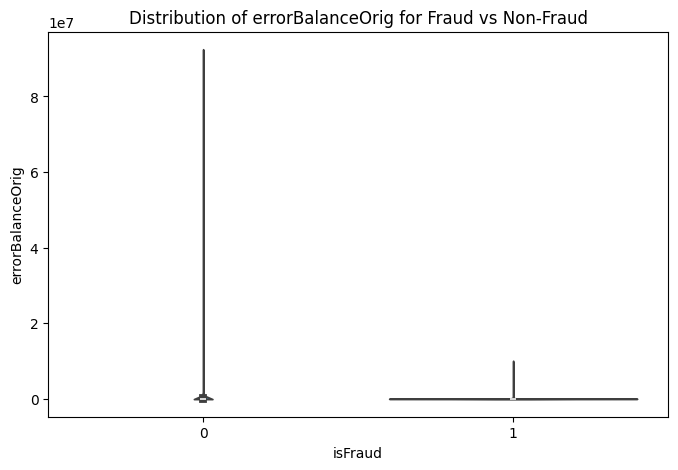

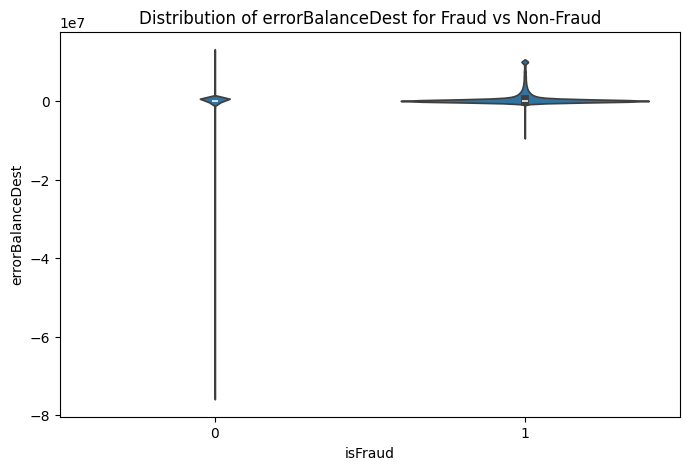

In [7]:
# 4: Exploratory Data Analysis Workflow

# 4.1: Knowing the Descriptive Statistics
print("\nDescriptive Statistics")
print(df.describe())

# 4.2: Fraud Distribution - Counting and percentage of Fraud v/s Non-Fraud
plt.figure(figsize=(5,4))
sns.countplot(x='isFraud', data=df, palette='pastel')
plt.title("Fraud vs Non-Fraud Transaction Count")
plt.xlabel("Transaction Type (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

fraud_percent = df['isFraud'].value_counts(normalize=True) * 100
print("\nFraud Percentage in Dataset:\n", fraud_percent)

# 4.3: Correlation Analysis - Checking relation between numerical columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# 4.4: Targeted Box Plots
# We specifically want to see 'amount' and the balances
target_cols = ['amount', 'oldbalanceOrg', 'newbalanceDest']

for col in target_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(x='isFraud', y=col, data=df, palette='Set2')
    plt.title(f"Impact of {col} on Fraud")
    # Using a limit helps see the boxes better if there are extreme outliers
    plt.yscale('log')
    plt.show()

# 4.5: Transaction Type vs Fraud
plt.figure(figsize=(10,6))
sns.countplot(x='type', hue='isFraud', data=df, palette='magma')
plt.title("Fraud Occurrence by Transaction Type")
plt.yscale('log') # Use log scale because Non-Fraud is so much higher
plt.show()

# 4.6: Validating the Custom Features using violinplot
cols_to_plot = ['errorBalanceOrig', 'errorBalanceDest']

for col in cols_to_plot:
    plt.figure(figsize=(8,5))
    sns.violinplot(x='isFraud', y=col, data=df)
    plt.title(f"Distribution of {col} for Fraud vs Non-Fraud")
    plt.show()

In [8]:
# 5: Data Transformation

#Performing One-Hot Encoding, converting 'Type' into numeric form
#One hot encoding is performed after EDA because the type columns requrired in the EDA part
if 'type' in df.columns:
  df = pd.get_dummies(df, columns=['type'], drop_first=True)
  print([col for col in df.columns if 'type_' in col])
  print("One-Hot Encoding Completed, new columns created for Transaction types")
else:
  print("Column 'type' already encoded or not present - skipping encoding.")

print("\nDATA TRANSFORMATION COMPLETED SUCCESSFULLY")
print("Final Dataset Shape:", df.shape)
print("\nList of Columns After Transformation:")
print(df.columns.tolist())

['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
One-Hot Encoding Completed, new columns created for Transaction types

DATA TRANSFORMATION COMPLETED SUCCESSFULLY
Final Dataset Shape: (6362620, 16)

List of Columns After Transformation:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'amount_category', 'errorBalanceOrig', 'errorBalanceDest', 'isZeroDest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


Applying SMOTE to balance classes...


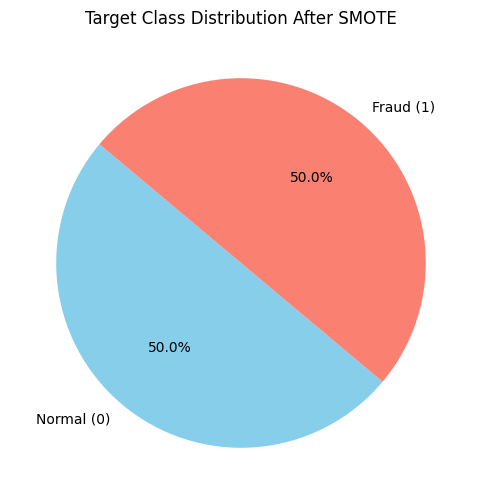

In [12]:
# 6: Before performing Model Builiding and Model Evaluation
# We have to prepare features - X and Y, splitting the data, scaling the data and applying SMOTE Technique to trained data

# 6.1: Preparing Features (X) and Target (y)
X = df.drop(['isFraud', 'amount_category', 'isFlaggedFraud'], axis=1, errors='ignore')
y = df['isFraud']

# 6.2: Spliting the data first (To prevent Data Leakage)
# This separates the data before we do any scaling or balancing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6.3: Scaling only the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6.4: Applying SMOTE to balance the Training Set
print("Applying SMOTE to balance classes...")
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)


# 6.5: VISUALIZING THE EFFECT OF SMOTE

#PIE CHART: Target Distribution AFTER SMOTE
resampled_counts = pd.Series(y_train_res).value_counts()
labels = ['Normal (0)', 'Fraud (1)']

plt.figure(figsize=(6, 6))
plt.pie(resampled_counts, labels=labels, autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=140)
plt.title("Target Class Distribution After SMOTE")
plt.show()

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

MODEL PERFORMANCE SUMMARY:
                 Model  Accuracy  Precision    Recall  F1-Score
2        Random Forest  0.999958   0.973763  0.993914  0.983735
1        Decision Tree  0.999910   0.939080  0.994522  0.966007
0  Logistic Regression  0.963594   0.032417  0.942788  0.062680


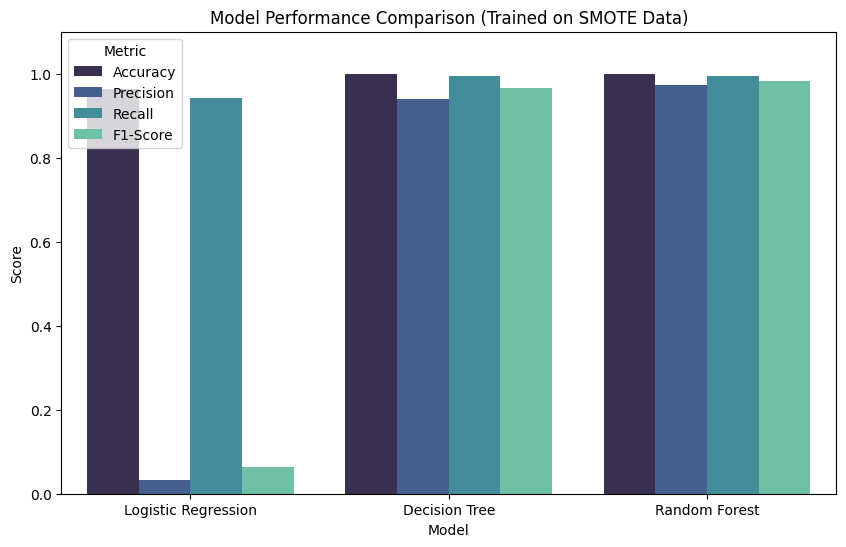

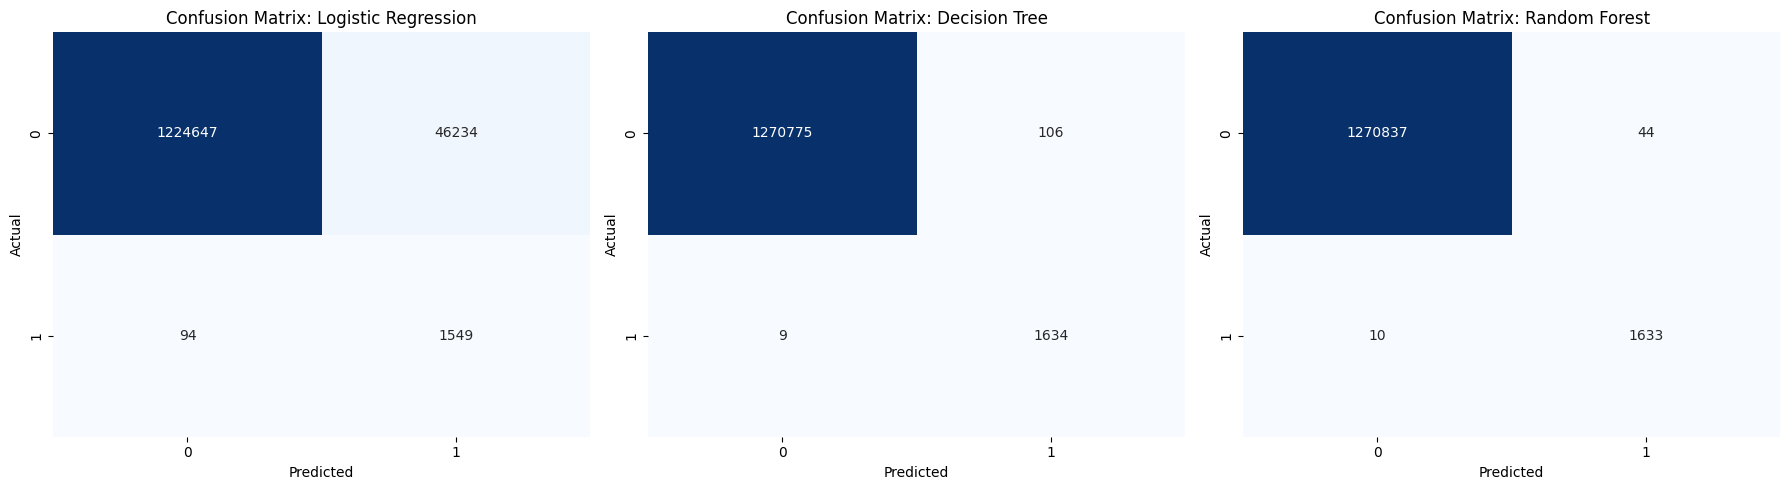

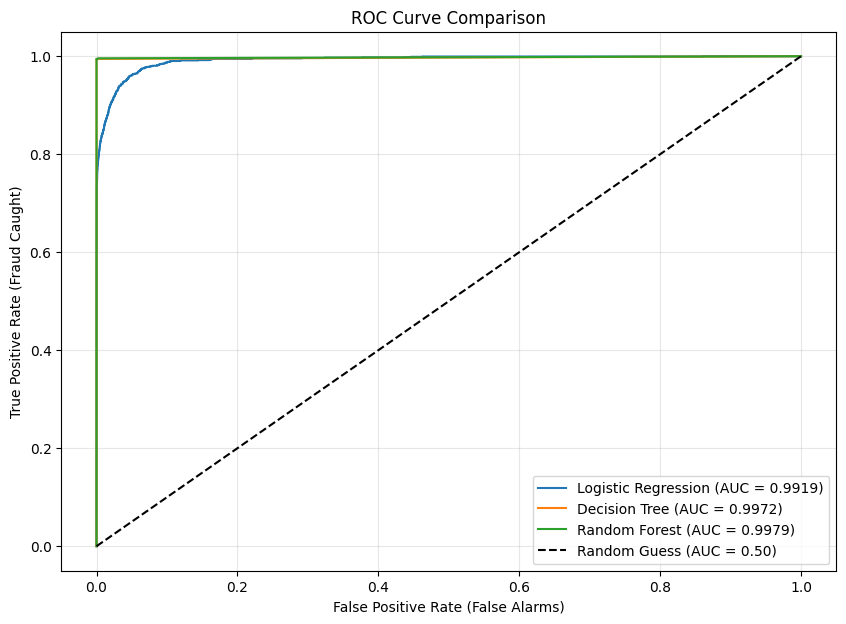


WINNER: Random Forest


['scaler.pkl']

In [14]:
# 7: MODEL BUILDING & COMPARISON

# 7.1: Importing the libraries neeeded for Model Building and Model Evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score, recall_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# 7.2: Initializing the  Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# 7.3: Training and Evaluating the Models
results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model

    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

# 7.4: Create Comparison Table
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
print("\nMODEL PERFORMANCE SUMMARY:")
print(df_results.sort_values(by="F1-Score", ascending=False))

# 7.5: Visualization (Bar Chart) - Model performances
plt.figure(figsize=(10, 6))
df_plot = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=df_plot, x="Model", y="Score", hue="Metric", palette="mako")
plt.title("Model Performance Comparison (Trained on SMOTE Data)")
plt.ylim(0, 1.1)
plt.show()

# 7.6 : Creating a confusion Matrix to know the values TP, TN, FP, FN
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    # Getting predictions for the specific model
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    # Creating a subplot for each model
    plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# 7.7 ROC-AUC Metric
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 7))

# We need the "Probability" scores, not just the 0/1 predictions
for name, model in trained_models.items():
    # Random Forest/Decision Tree use predict_probaba
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

# Plot the "Random Guess" diagonal line
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.50)")

plt.xlabel("False Positive Rate (False Alarms)")
plt.ylabel("True Positive Rate (Fraud Caught)")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 7.8: Identify and SAVE the Best Model
best_model_name = df_results.loc[df_results['F1-Score'].idxmax()]['Model']
print(f"\nBest Model: {best_model_name}")

# 7.9: Saving the trained models
joblib.dump(trained_models[best_model_name], 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')